# Topic 4 (Part 1) — Hands-On: Splitting Data Honestly, and Breaking (then Fixing) a Deep Network
## Train/Validation/Test Splits, Overfitting, and Vanishing/Exploding Gradients

> **Objective:** In the theory session we learned *why* we need a validation set, what overfitting looks like, and why deep networks can fail to train. Now we'll build all of it ourselves: a real train/val/test split, a model-selection pipeline that never peeks at the test set early, a generic multi-layer network we verify with gradient checking, and a live demonstration of how weight initialization alone can make or break whether a deep network trains at all.

### What We Will Cover
1. **Splitting** data into train/validation/test ourselves
2. **Selecting** a model using only train + validation, then checking test performance exactly once
3. **Building** a generic, variable-depth network and verifying it with gradient checking
4. **Tracing** vanishing/exploding gradients through that network
5. **Proving** that weight initialization alone can make or break whether a deep network trains at all

---
## 1. Setup — Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print("Libraries loaded!")

Libraries loaded!


---
## 2. Build a Train / Validation / Test Split Function

Let's write a reusable function that shuffles the data and splits it three ways. We'll reuse this on every dataset for the rest of the notebook.

In [2]:
def train_val_test_split(X, y, train_frac=0.70, val_frac=0.15, seed=0):
    """Shuffle (X, y) and split into train / validation / test sets."""
    n = len(X)
    rng = np.random.RandomState(seed)
    indices = rng.permutation(n)

    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_idx = indices[:n_train]
    val_idx = indices[n_train:n_train + n_val]
    test_idx = indices[n_train + n_val:]

    return (X[train_idx], y[train_idx]), (X[val_idx], y[val_idx]), (X[test_idx], y[test_idx])


# Quick test on a toy array
X_dummy = np.arange(20).reshape(-1, 1)
y_dummy = np.arange(20)
(X_tr, y_tr), (X_va, y_va), (X_te, y_te) = train_val_test_split(X_dummy, y_dummy, seed=1)

print(f"Train: {len(X_tr)} examples -> {y_tr}")
print(f"Val:   {len(X_va)} examples -> {y_va}")
print(f"Test:  {len(X_te)} examples -> {y_te}")
print(f"\nNo overlap between sets: {len(set(y_tr) & set(y_va) & set(y_te)) == 0}")

Train: 14 examples -> [ 3 16  6 10  2 14  4 17  7  1 13  0 19 18]
Val:   3 examples -> [ 9 15  8]
Test:  3 examples -> [12 11  5]

No overlap between sets: True


---
## 3. Model Selection Without Cheating

Here's the real discipline a validation set buys us: we'll fit polynomials of many different degrees, use **only the validation set** to pick the best one, and only *after* that decision is locked in do we check performance on the **test set** — exactly once.

Train: 20  Validation: 10  Test: 10

Best degree found using ONLY train+validation data: 5
Final, one-time test set performance: MSE = 0.0317


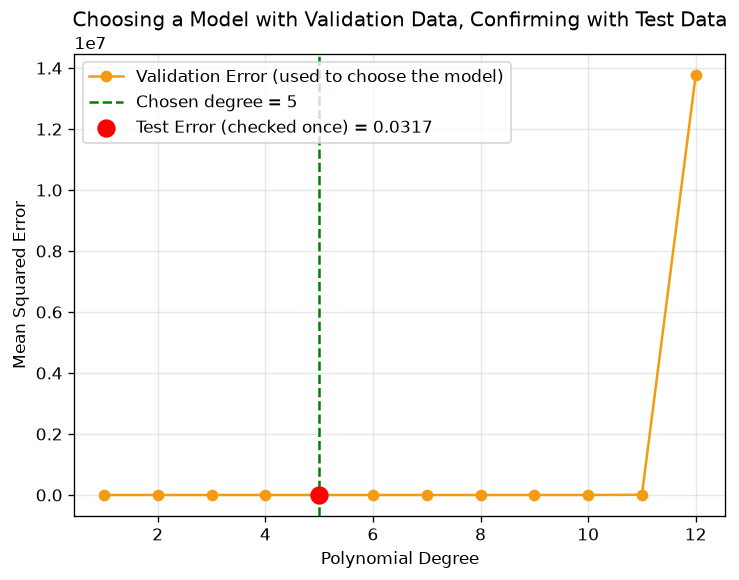


Notice: the test error is close to the validation error at the chosen degree --
that's what an HONEST evaluation looks like. If we'd instead picked the degree
that minimized TEST error directly, we'd be cheating, even if by accident.


In [3]:
# Build a noisy dataset from a known function, then split it
np.random.seed(0)

def true_fn(x):
    return np.sin(x)

n_samples = 40
X_all = np.sort(np.random.uniform(-3, 3, n_samples)).reshape(-1, 1)
y_all = true_fn(X_all).flatten() + np.random.normal(0, 0.2, n_samples)

(X_train, y_train), (X_val, y_val), (X_test, y_test) = train_val_test_split(X_all, y_all, train_frac=0.5, val_frac=0.25, seed=0)
print(f"Train: {len(X_train)}  Validation: {len(X_val)}  Test: {len(X_test)}")

# Step 1: try many model complexities, choosing based on VALIDATION error only
degrees = list(range(1, 13))
val_errors = []

for deg in degrees:
    coeffs = np.polyfit(X_train.flatten(), y_train, deg)
    val_pred = np.polyval(coeffs, X_val.flatten())
    val_errors.append(np.mean((val_pred - y_val) ** 2))

best_degree = degrees[np.argmin(val_errors)]
print(f"\nBest degree found using ONLY train+validation data: {best_degree}")

# Step 2: NOW, and only now, retrain on train+val and check the test set ONCE
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])
final_coeffs = np.polyfit(X_trainval.flatten(), y_trainval, best_degree)

test_pred = np.polyval(final_coeffs, X_test.flatten())
test_mse = np.mean((test_pred - y_test) ** 2)
print(f"Final, one-time test set performance: MSE = {test_mse:.4f}")

plt.figure(figsize=(7, 5))
plt.plot(degrees, val_errors, 'o-', color='#f39c12', label='Validation Error (used to choose the model)')
plt.axvline(x=best_degree, color='green', linestyle='--', label=f'Chosen degree = {best_degree}')
plt.scatter([best_degree], [test_mse], color='red', s=100, zorder=5, label=f'Test Error (checked once) = {test_mse:.4f}')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error')
plt.title('Choosing a Model with Validation Data, Confirming with Test Data')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nNotice: the test error is close to the validation error at the chosen degree --")
print("that's what an HONEST evaluation looks like. If we'd instead picked the degree")
print("that minimized TEST error directly, we'd be cheating, even if by accident.")

---
## 4. Building a Generic, Variable-Depth Network

So far every network we've built has had a fixed number of layers. Let's generalize: write `init_network`, `forward_deep`, and `backward_deep` functions that work for **any** list of layer sizes and **any** choice of hidden-layer activation.

In [4]:
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)

def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    return (x > 0).astype(float)


def init_network(layer_sizes, weight_scale_fn, seed=0):
    """layer_sizes, e.g. [2, 10, 10, 1], describes input -> hidden -> ... -> output.
    weight_scale_fn(fan_in) returns the std-dev to use for that layer's weights."""
    rng = np.random.RandomState(seed)
    Ws, bs = [], []
    for i in range(len(layer_sizes) - 1):
        scale = weight_scale_fn(layer_sizes[i])
        Ws.append(rng.randn(layer_sizes[i], layer_sizes[i + 1]) * scale)
        bs.append(np.zeros((1, layer_sizes[i + 1])))
    return Ws, bs


def forward_deep(X, Ws, bs, activation):
    """Hidden layers use `activation`; the output layer always uses Sigmoid (binary classification)."""
    zs, activations = [], [X]
    a = X
    n = len(Ws)
    for i in range(n):
        z = a.dot(Ws[i]) + bs[i]
        a = sigmoid(z) if i == n - 1 else activation(z)
        zs.append(z)
        activations.append(a)
    return activations[-1], (zs, activations)


def backward_deep(y_true, Ws, cache, activation_derivative):
    """Backpropagate through every layer, reusing each layer's error signal for the one before it."""
    zs, activations = cache
    n = len(Ws)
    dz = activations[-1] - y_true  # combined Sigmoid + cross-entropy gradient
    grads_W, grads_b = [None] * n, [None] * n
    for i in reversed(range(n)):
        grads_W[i] = activations[i].T.dot(dz) / len(y_true)
        grads_b[i] = np.mean(dz, axis=0, keepdims=True)
        if i > 0:
            dz = dz.dot(Ws[i].T) * activation_derivative(zs[i - 1])
    return grads_W, grads_b


def compute_loss(a_out, y_true):
    eps = 1e-8
    return -np.mean(y_true * np.log(a_out + eps) + (1 - y_true) * np.log(1 - a_out + eps))


print("Generic network functions defined: init_network, forward_deep, backward_deep, compute_loss")

Generic network functions defined: init_network, forward_deep, backward_deep, compute_loss


---
## 5. Gradient Checking the Generic Implementation

This is a genuinely new, more complex implementation than last session's fixed 2-layer version — different code paths for arbitrary depth are exactly where subtle bugs hide. Before trusting it, let's verify it the same way we did last session: compare the analytic gradient against a numerical one.

In [5]:
# A small toy network and dataset for a fast, thorough check
np.random.seed(1)
X_check = np.random.randn(6, 3)
y_check = (np.random.rand(6, 1) > 0.5).astype(float)

layer_sizes = [3, 5, 4, 1]
Ws, bs = init_network(layer_sizes, weight_scale_fn=lambda n: 0.5, seed=2)

a_out, cache = forward_deep(X_check, Ws, bs, relu)
grads_W, grads_b = backward_deep(y_check, Ws, cache, relu_derivative)

epsilon = 1e-5
overall_max_diff = 0

for layer_idx, W in enumerate(Ws):
    max_diff = 0
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            original = W[i, j]

            W[i, j] = original + epsilon
            a_plus, _ = forward_deep(X_check, Ws, bs, relu)
            loss_plus = compute_loss(a_plus, y_check)

            W[i, j] = original - epsilon
            a_minus, _ = forward_deep(X_check, Ws, bs, relu)
            loss_minus = compute_loss(a_minus, y_check)

            W[i, j] = original  # restore

            numerical_grad = (loss_plus - loss_minus) / (2 * epsilon)
            analytic_grad = grads_W[layer_idx][i, j]
            max_diff = max(max_diff, abs(numerical_grad - analytic_grad))

    overall_max_diff = max(overall_max_diff, max_diff)
    print(f"Layer {layer_idx} (shape {W.shape}): largest analytic-vs-numerical difference = {max_diff:.10f}")

print(f"\nLargest difference across ALL layers: {overall_max_diff:.10f}")
print("PASSED -- backward_deep() is correct for arbitrary depth!" if overall_max_diff < 1e-4 else "FAILED")

Layer 0 (shape (3, 5)): largest analytic-vs-numerical difference = 0.0000000015
Layer 1 (shape (5, 4)): largest analytic-vs-numerical difference = 0.0000000018
Layer 2 (shape (4, 1)): largest analytic-vs-numerical difference = 0.0000000009

Largest difference across ALL layers: 0.0000000018
PASSED -- backward_deep() is correct for arbitrary depth!


---
## 6. Tracing Vanishing & Exploding Gradients Through Our Own Functions

Now let's use `init_network` / `forward_deep` / `backward_deep` to reproduce the vanishing/exploding comparison from the theory session — but this time with the exact functions we just verified.

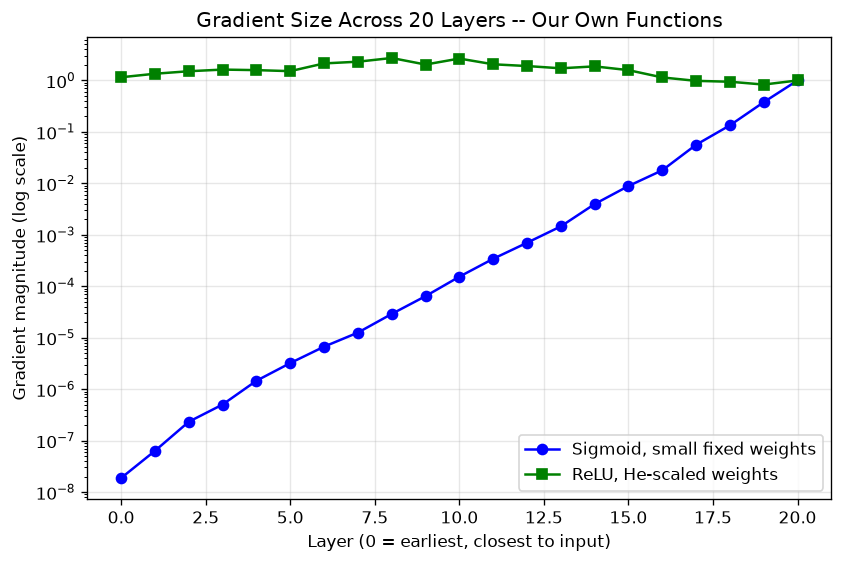

First-layer gradient -- Sigmoid setup: 1.88e-08   ReLU setup: 1.15e+00


In [6]:
def gradient_trace_through_network(layer_sizes, activation, activation_derivative, weight_scale_fn, seed=0):
    """Send a single example through the network, then backprop a gradient of 1.0 from the
    output and record its size at every layer."""
    rng = np.random.RandomState(seed)
    X_single = rng.randn(1, layer_sizes[0])
    Ws, bs = init_network(layer_sizes, weight_scale_fn, seed=seed)

    zs, activations = [], [X_single]
    a = X_single
    n = len(Ws)
    for i in range(n):
        z = a.dot(Ws[i]) + bs[i]
        a = activation(z)  # every layer uses the SAME activation here, purely to trace gradient size
        zs.append(z)
        activations.append(a)

    grad = np.ones((1, layer_sizes[-1]))
    magnitudes = [np.mean(np.abs(grad))]
    for i in reversed(range(n)):
        grad = (grad * activation_derivative(zs[i])).dot(Ws[i].T)
        magnitudes.append(np.mean(np.abs(grad)))
    return magnitudes[::-1]

layer_sizes = [20] * 21  # 20 layers, all the same width, for a clean comparison

vanishing = gradient_trace_through_network(layer_sizes, sigmoid, sigmoid_derivative, weight_scale_fn=lambda n: 0.5)
stable = gradient_trace_through_network(layer_sizes, relu, relu_derivative, weight_scale_fn=lambda n: np.sqrt(2.0 / n))

plt.figure(figsize=(8, 5))
plt.semilogy(vanishing, 'o-', color='blue', label='Sigmoid, small fixed weights')
plt.semilogy(stable, 's-', color='green', label='ReLU, He-scaled weights')
plt.xlabel('Layer (0 = earliest, closest to input)')
plt.ylabel('Gradient magnitude (log scale)')
plt.title('Gradient Size Across 20 Layers -- Our Own Functions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"First-layer gradient -- Sigmoid setup: {vanishing[0]:.2e}   ReLU setup: {stable[0]:.2e}")

---
## 7. Does Fixing the Initialization Actually Fix Training?

A gradient trace at initialization is convincing, but let's settle it by actually training. We'll build **the same 5-hidden-layer ReLU network, on the same data**, and change *only* the weight initialization scale — nothing else.

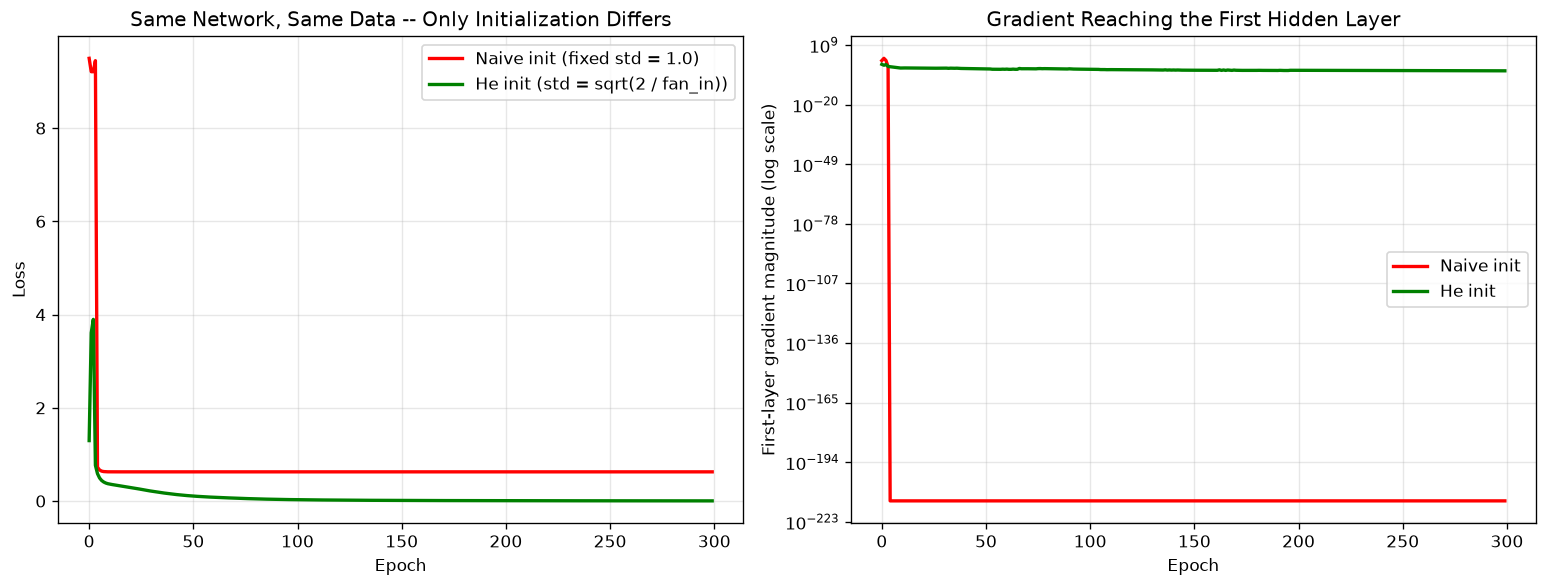

Naive init -- loss[0]: 9.4975   loss[-1]: 0.6263
He init    -- loss[0]: 1.2966   loss[-1]: 0.0037

For reference, ln(2) = 0.6931 is the loss of a coin-flip guesser.

Dead ReLU units per hidden layer (units that output 0 for EVERY training example):
  Naive init: layer 0: 0/10, layer 1: 4/10, layer 2: 2/10, layer 3: 6/10, layer 4: 3/10
  He init:    layer 0: 0/10, layer 1: 0/10, layer 2: 0/10, layer 3: 5/10, layer 4: 5/10

Both networks end up with SOME dead units -- a little sparsity is normal for ReLU.
But look at WHERE they first appear: in the naive network, layer 1 (right next to
the input) already has dead units, so the damage compounds through every layer after
it. In the He-initialized network, layers 0-2 stay completely alive, and dead units
only show up much later. Same architecture, same data, same optimizer -- only the
initialization scale differed, and it decided whether the network died early or late.


In [7]:
# The familiar two-class dataset
np.random.seed(42)
n_points = 50
class_0 = np.random.randn(n_points, 2) + np.array([0, 0])
class_1 = np.random.randn(n_points, 2) + np.array([3, 3])
X = np.vstack([class_0, class_1])
y = np.array([0]*n_points + [1]*n_points).reshape(-1, 1)

def train_network(layer_sizes, weight_scale_fn, epochs, lr, seed=0):
    Ws, bs = init_network(layer_sizes, weight_scale_fn, seed=seed)
    n = len(Ws)
    losses, first_layer_grad_norms = [], []
    for epoch in range(epochs):
        a_out, cache = forward_deep(X, Ws, bs, relu)
        losses.append(compute_loss(a_out, y))
        grads_W, grads_b = backward_deep(y, Ws, cache, relu_derivative)
        first_layer_grad_norms.append(np.mean(np.abs(grads_W[0])))
        for i in range(n):
            Ws[i] -= lr * grads_W[i]
            bs[i] -= lr * grads_b[i]
    return losses, first_layer_grad_norms, Ws, bs

layer_sizes = [2, 10, 10, 10, 10, 10, 1]  # 5 hidden layers
epochs, lr = 300, 0.1

# "Naive": a fixed weight scale that ignores how many layers/neurons feed into each layer
losses_naive, grad_naive, Ws_naive, bs_naive = train_network(layer_sizes, weight_scale_fn=lambda n: 1.0, epochs=epochs, lr=lr)

# "He initialization": scaled by sqrt(2 / fan_in), the standard choice for ReLU networks
losses_he, grad_he, Ws_he, bs_he = train_network(layer_sizes, weight_scale_fn=lambda n: np.sqrt(2.0 / n), epochs=epochs, lr=lr)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(losses_naive, color='red', linewidth=2, label='Naive init (fixed std = 1.0)')
axes[0].plot(losses_he, color='green', linewidth=2, label='He init (std = sqrt(2 / fan_in))')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Same Network, Same Data -- Only Initialization Differs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].semilogy(grad_naive, color='red', linewidth=2, label='Naive init')
axes[1].semilogy(grad_he, color='green', linewidth=2, label='He init')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('First-layer gradient magnitude (log scale)')
axes[1].set_title('Gradient Reaching the First Hidden Layer')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Naive init -- loss[0]: {losses_naive[0]:.4f}   loss[-1]: {losses_naive[-1]:.4f}")
print(f"He init    -- loss[0]: {losses_he[0]:.4f}   loss[-1]: {losses_he[-1]:.4f}")
print(f"\nFor reference, ln(2) = {np.log(2):.4f} is the loss of a coin-flip guesser.")

# Let's not just SPECULATE that ReLU units died -- let's actually count them.
def count_dead_units(X, Ws, bs):
    """A unit is 'dead' if it outputs exactly 0 for every single training example."""
    a = X
    counts = []
    for i in range(len(Ws) - 1):  # hidden layers only, not the output layer
        z = a.dot(Ws[i]) + bs[i]
        a = relu(z)
        dead = int(np.sum(np.all(a == 0, axis=0)))
        counts.append((dead, a.shape[1]))
    return counts

print("\nDead ReLU units per hidden layer (units that output 0 for EVERY training example):")
print("  Naive init:", ", ".join(f"layer {i}: {d}/{t}" for i, (d, t) in enumerate(count_dead_units(X, Ws_naive, bs_naive))))
print("  He init:   ", ", ".join(f"layer {i}: {d}/{t}" for i, (d, t) in enumerate(count_dead_units(X, Ws_he, bs_he))))

print("\nBoth networks end up with SOME dead units -- a little sparsity is normal for ReLU.")
print("But look at WHERE they first appear: in the naive network, layer 1 (right next to")
print("the input) already has dead units, so the damage compounds through every layer after")
print("it. In the He-initialized network, layers 0-2 stay completely alive, and dead units")
print("only show up much later. Same architecture, same data, same optimizer -- only the")
print("initialization scale differed, and it decided whether the network died early or late.")

---
## 8. Summary

### What We Built:
1. A reusable **`train_val_test_split()`** function
2. A model-selection pipeline that picks a polynomial degree using only train + validation data, then checks the test set exactly once
3. Generic **`init_network` / `forward_deep` / `backward_deep`** functions that work for any depth or hidden activation
4. A **gradient checker** proving our generic implementation is correct, no matter how deep the network is
5. A live, trained proof that **weight initialization alone** can be the difference between a network that learns and one that doesn't

### Key Takeaways:
1. A validation set lets us tune freely; a test set checked only once is what keeps our final number honest
2. Overfitting shows up as validation error rising while training error keeps falling — model complexity has a sweet spot
3. Vanishing/exploding gradients come from the chain rule multiplying many factors together across layers
4. The exact same architecture can fail or succeed to train, purely based on how its weights are scaled at initialization
5. Always gradient-check a new implementation, especially once it gets more general/complex than what you've verified before